# Exploratory Data Analysis (EDA) for Machine Learning & Neural Networks
#SC211 CpE Special Course: Introduction to Neural Networks

**Dataset:** UCI Wine Quality (Red Wine)

-has numeric features, suitable for both classification (quality bucket) and regression (quality score), which makes it a good sandbox for neural network preprocessing decisions

In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Dimensionality reduction & ML utilities
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Missing value visualization
try:
    import missingno as msno
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "missingno", "--quiet"])
    import missingno as msno

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

Sets up essential libraries for data analysis (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (scikit-learn). Missing value visualization (`missingno`) is installed if needed. Configures styling with Times New Roman font.

## 1. Load & Understand the Dataset

In [2]:
url = "C:\\Users\\gonza\\Music\\Codes\\wine+quality\\winequality-white.csv" \
""
#You can change the URL into a local path if you have downloaded the dataset to your local machine. For example:
# url = "path/to/your/local/winequality-red.csv"

df = pd.read_csv(url, sep=";")
print(df.shape)
df.head()

(4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6


Loads the UCI Wine Quality dataset (1599 red wine samples × 12 features). Features include alcohol %, acidity levels, sulfur dioxide, etc. Target: quality score (0-10).

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
pd.set_option('display.max_rows', None)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.00,0.270,0.36,20.70,0.045,45.0,170.0,1.001000,3.00,0.45,8.800000,6
1,6.30,0.300,0.34,1.60,0.049,14.0,132.0,0.994000,3.30,0.49,9.500000,6
2,8.10,0.280,0.40,6.90,0.050,30.0,97.0,0.995100,3.26,0.44,10.100000,6
3,7.20,0.230,0.32,8.50,0.058,47.0,186.0,0.995600,3.19,0.40,9.900000,6
4,7.20,0.230,0.32,8.50,0.058,47.0,186.0,0.995600,3.19,0.40,9.900000,6
5,8.10,0.280,0.40,6.90,0.050,30.0,97.0,0.995100,3.26,0.44,10.100000,6
6,6.20,0.320,0.16,7.00,0.045,30.0,136.0,0.994900,3.18,0.47,9.600000,6
7,7.00,0.270,0.36,20.70,0.045,45.0,170.0,1.001000,3.00,0.45,8.800000,6
8,6.30,0.300,0.34,1.60,0.049,14.0,132.0,0.994000,3.30,0.49,9.500000,6
9,8.10,0.220,0.43,1.50,0.044,28.0,129.0,0.993800,3.22,0.45,11.000000,6


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


Prints data types and memory usage. Checks that all 12 features are numeric floats with **no missing values**—critical before neural network training.

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


Shows mean, std, min/max for each feature. Identifies ranges and spread. E.g., alcohol ranges 8.4%-14.9%, quality 3-8.

## 2. Missing Value Analysis

Even though this dataset is clean, always check — neural networks are sensitive to NaNs and will fail silently or error out during training.

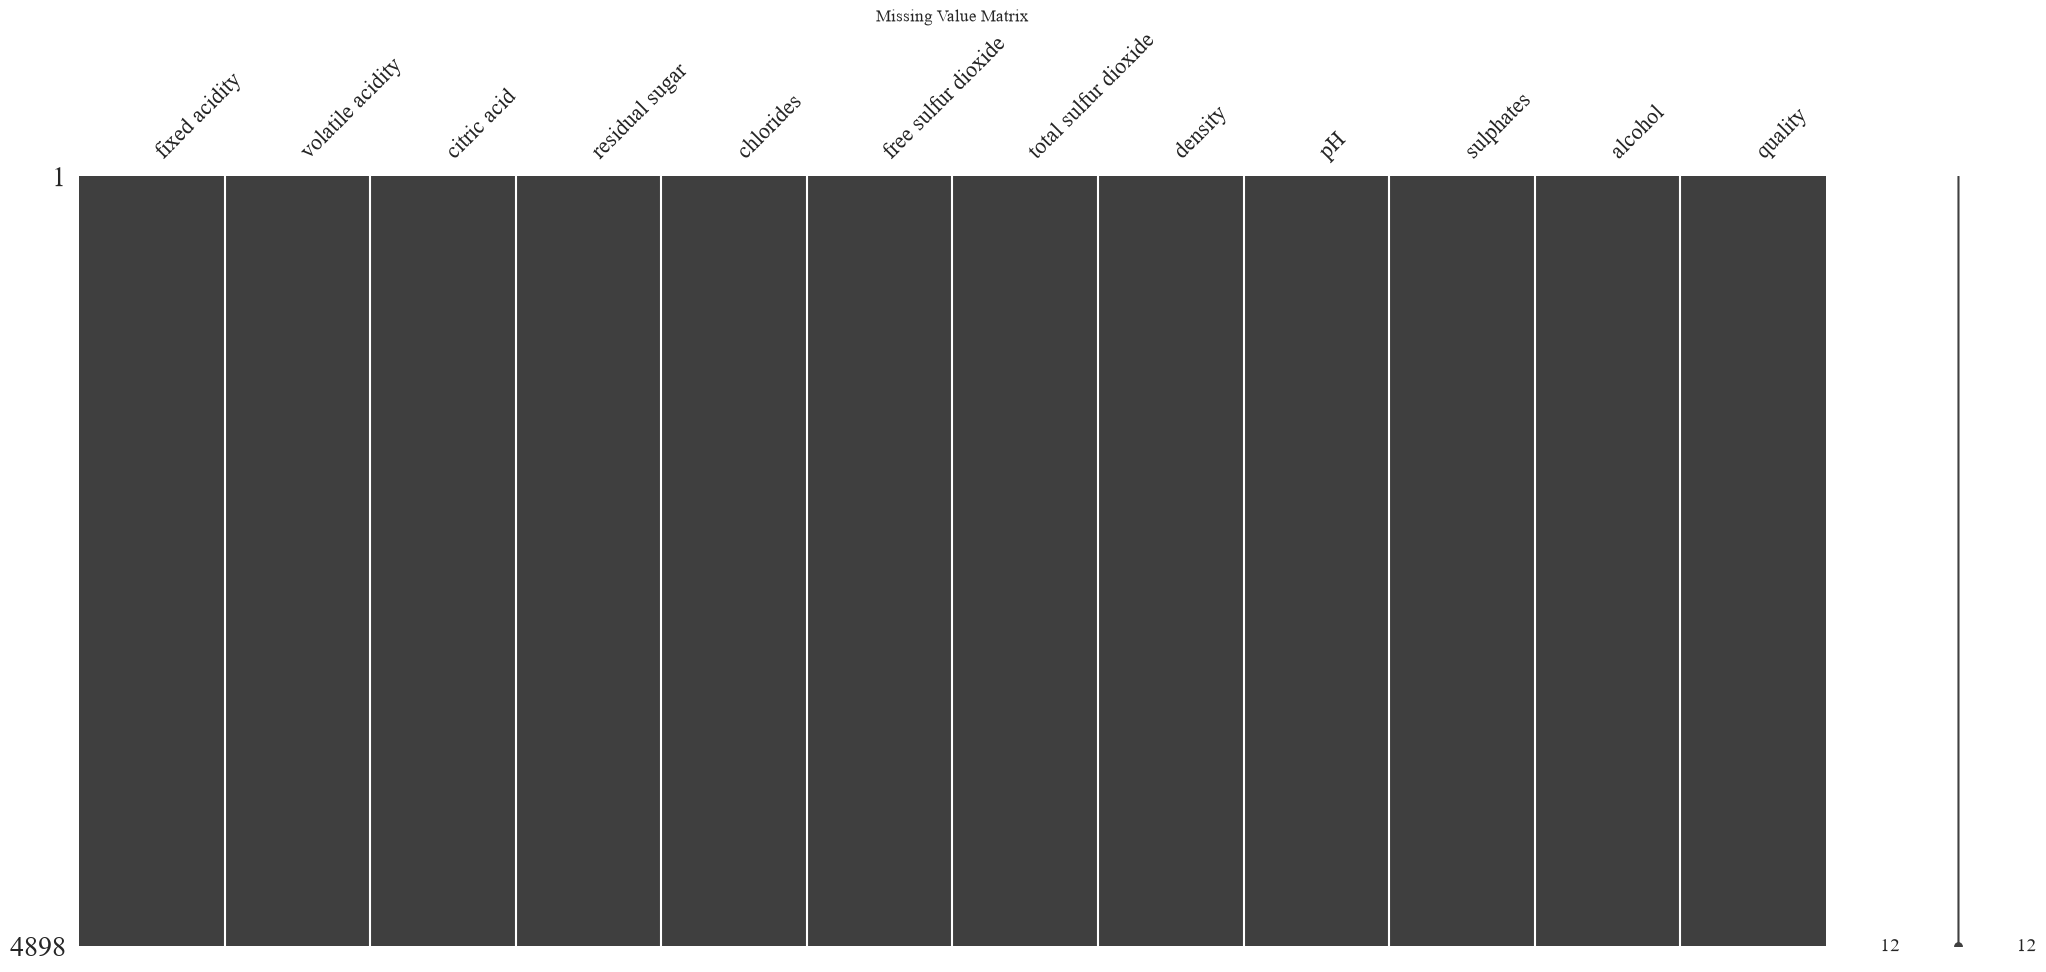

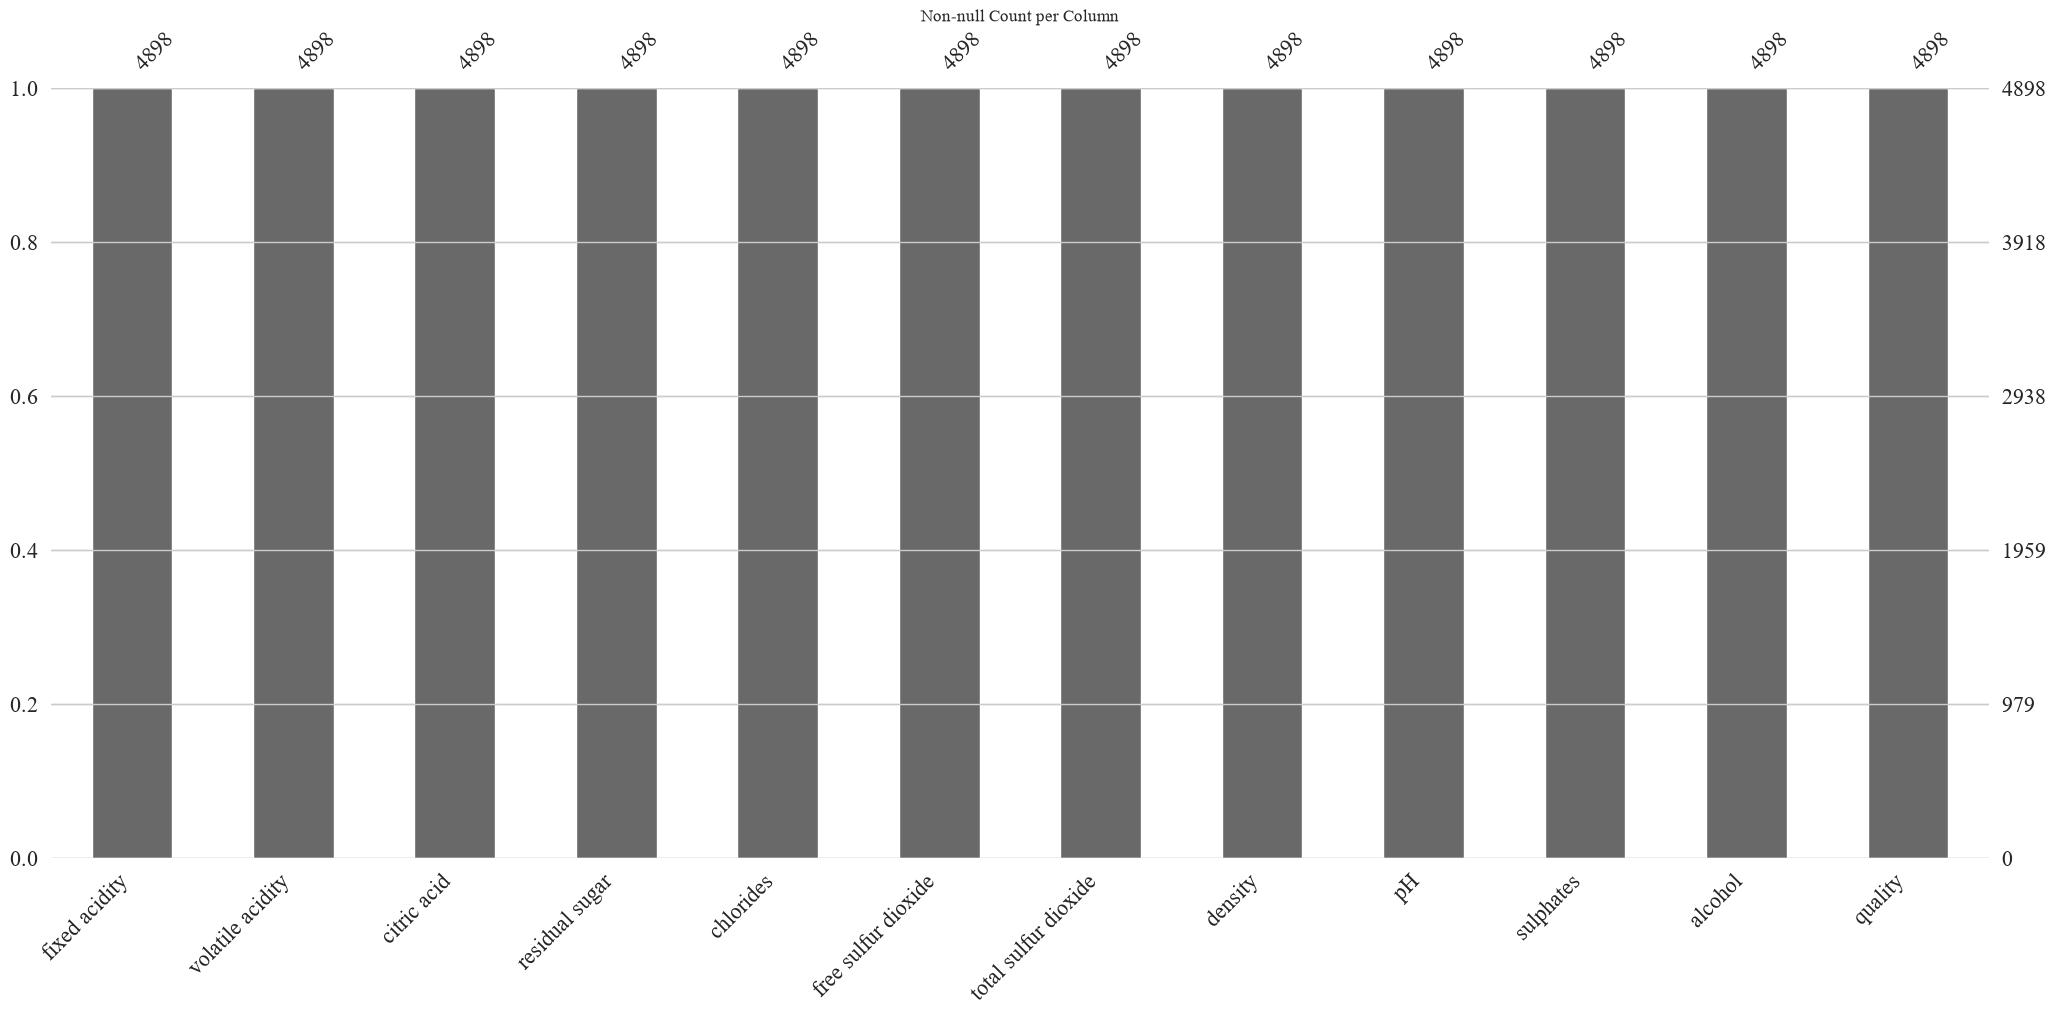

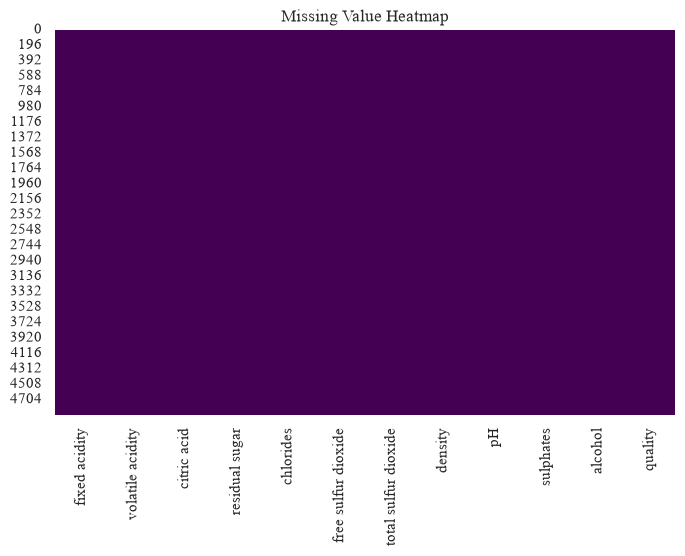

In [8]:
# Missingno matrix - shows presence/absence of data per column
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

# Bar version - count of non-null values per column
msno.bar(df)
plt.title("Non-null Count per Column")
plt.show()

# As a heatmap check
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


**Missing Value Matrix/Bar/Heatmap:**
- Shows dataset is **complete** (no NaNs)
- Critical before NN training—missing values will cause silent failures or errors
- **Interpretation:** Green bar = 100% present data across all 1599 rows
- All three visualizations confirm data integrity for downstream modeling

## 3. Univariate Analysis — Distribution of Each Variable

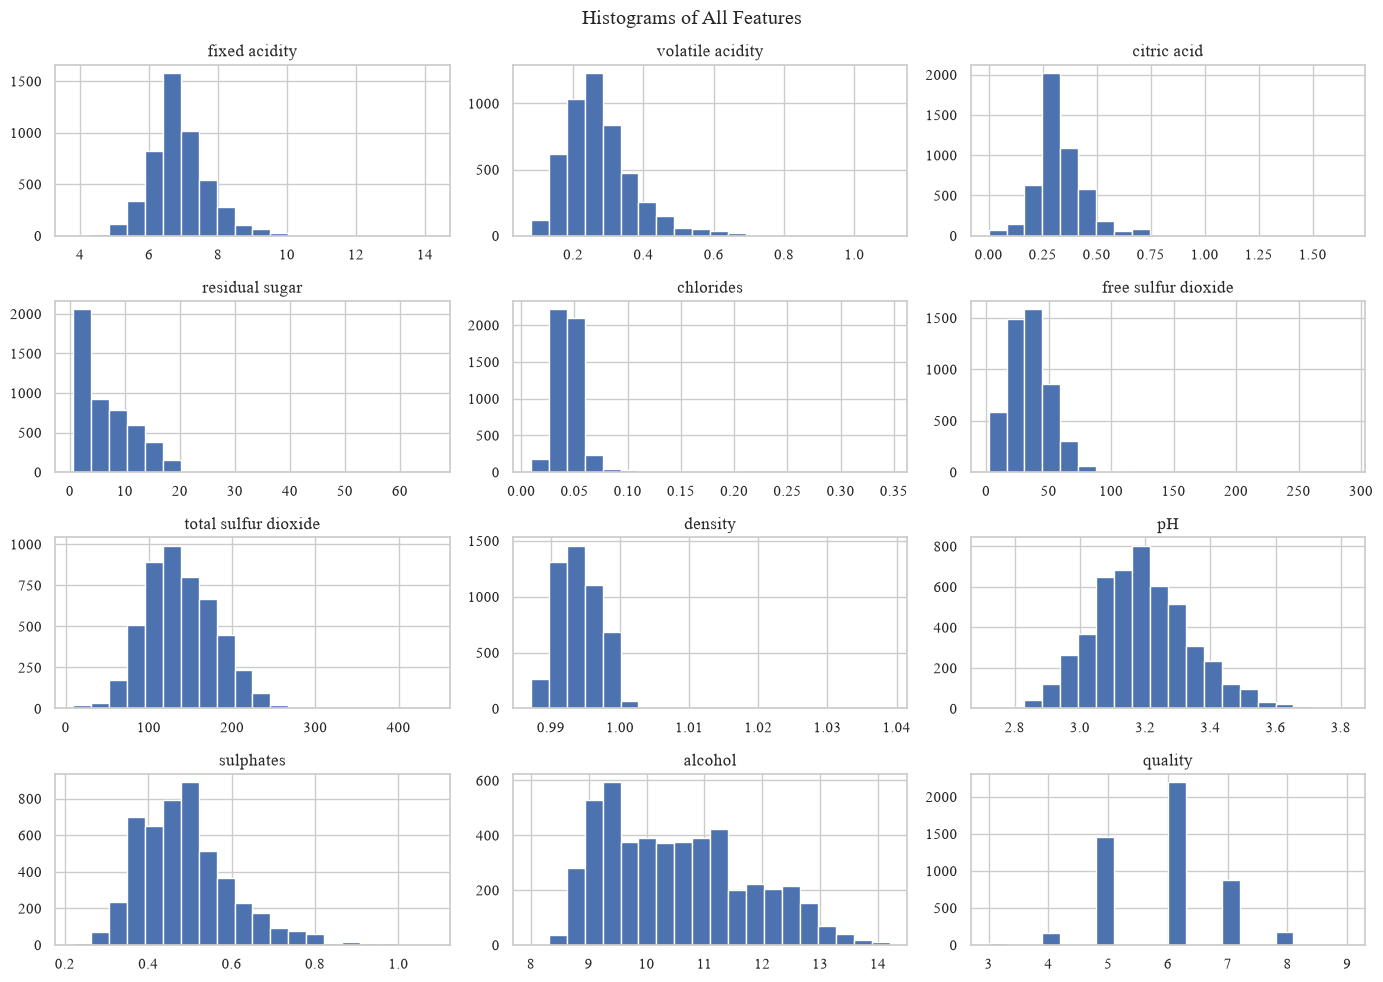

In [9]:
# Histogram + KDE for every numeric feature
df.hist(bins=20, figsize=(14, 10))
plt.suptitle("Histograms of All Features")
plt.tight_layout()
plt.show()


- 12 subplots showing distribution of each feature
- **Interpretation:** Most features are **right-skewed** (long tail right). Alcohol peaks ~9.5%, citric acid bimodal (clusters at 0 and 0.5).

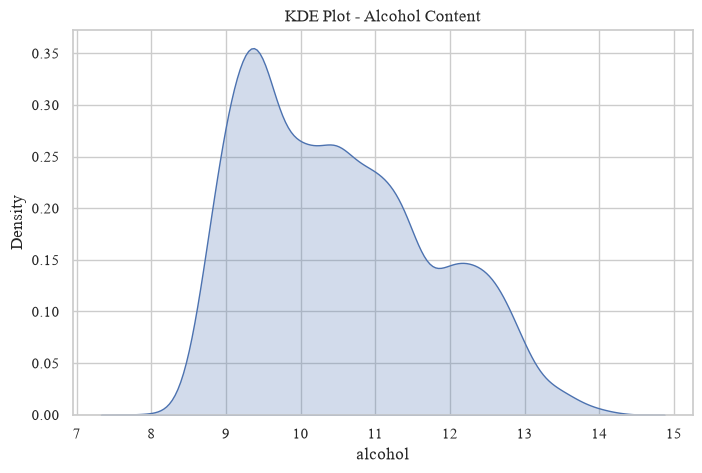

In [10]:
# KDE plot for a single feature (density curve)
plt.figure(figsize=(8,5))
sns.kdeplot(df["alcohol"], fill=True)
plt.title("KDE Plot - Alcohol Content")
plt.show()


- Smooth density curve; unimodal, slightly right-skewed
- **Key insight:** Alcohol ~9-10% most common

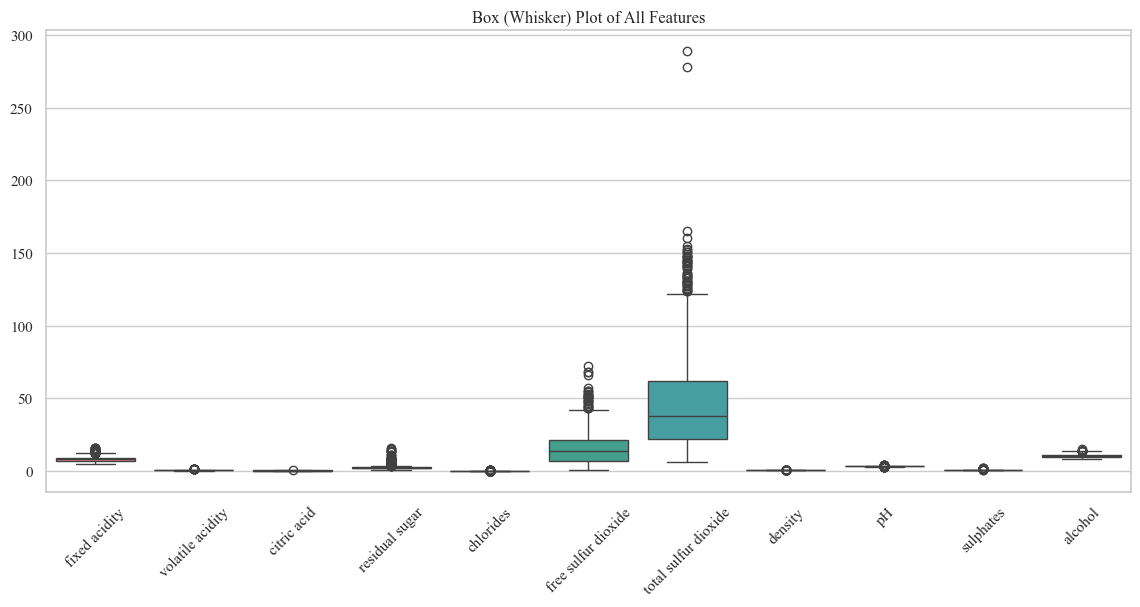

In [ ]:
# Box / Whisker plot - spot outliers per feature
plt.figure(figsize=(14,6))
sns.boxplot(data=df.drop(columns=["quality"]))
plt.xticks(rotation=45) 
plt.title("Box (Whisker) Plot of All Features")
plt.show()


- Shows median, quartiles, outliers for all features
- **Interpretation:** Sulphates, alcohol, chlorides have **outliers** (points beyond whiskers)—important for NN input scaling decisions

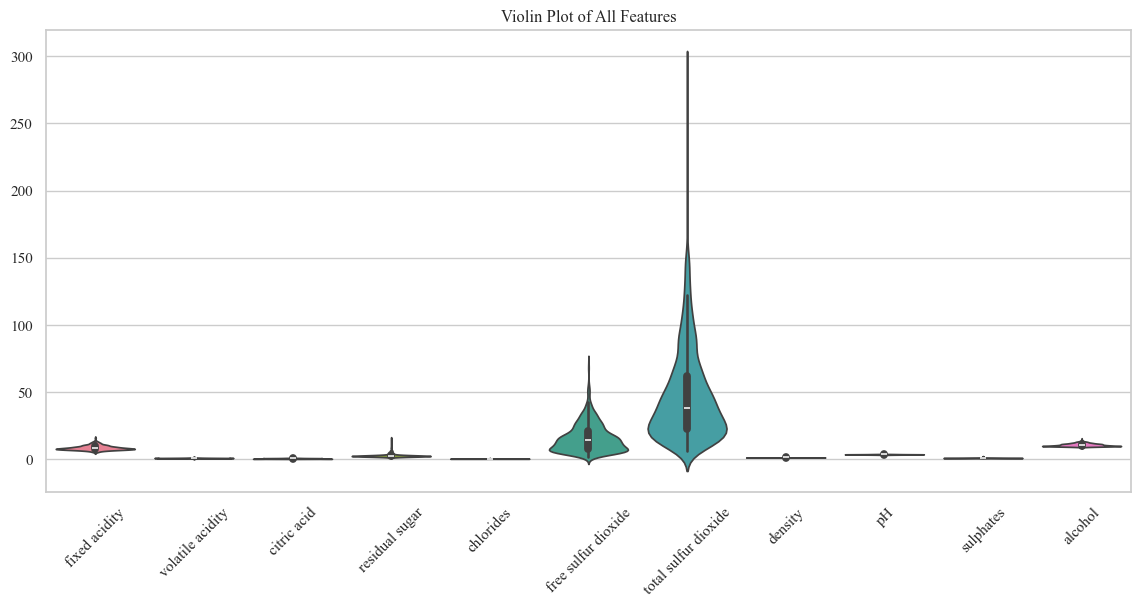

In [ ]:
# Violin plot - distribution shape + spread combined
plt.figure(figsize=(14,6))
sns.violinplot(data=df.drop(columns=["quality"]))
plt.xticks(rotation=45)
plt.title("Violin Plot of All Features")
plt.show()


- Combines box plot + density shape
- **Interpretation:** Shows width of distribution at each value range; reveals multimodal distributions

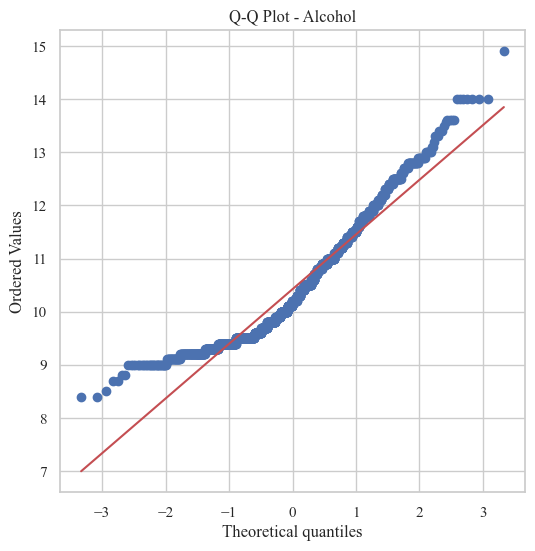

In [ ]:
# Q-Q plot - check normality assumption (important for some NN input scaling choices)
plt.figure(figsize=(6,6))
stats.probplot(df["alcohol"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Alcohol")
plt.show()


- Points deviate from diagonal line → **not normally distributed**
- **Why it matters:** Some NN preprocessing methods assume normality; StandardScaler still works well

## 4. Bivariate Analysis — Relationships Between Two Variables

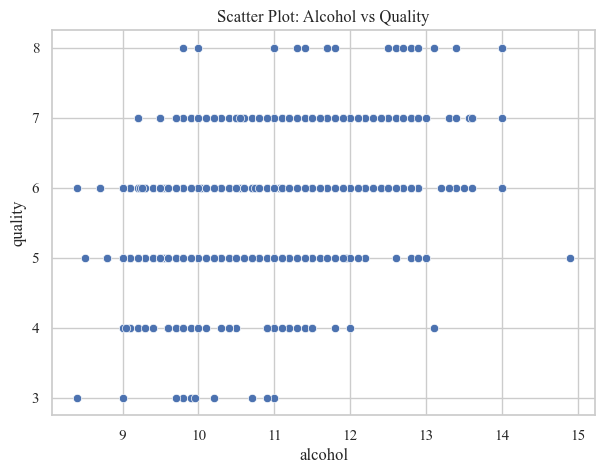

In [ ]:
# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="alcohol", y="quality")
plt.title("Scatter Plot: Alcohol vs Quality")
plt.show()


- **Interpretation:** Weak-to-moderate positive correlation—higher alcohol tends toward higher quality, but scatter is wide. R² likely ~0.23-0.25 (alcohol explains ~25% of quality variance).

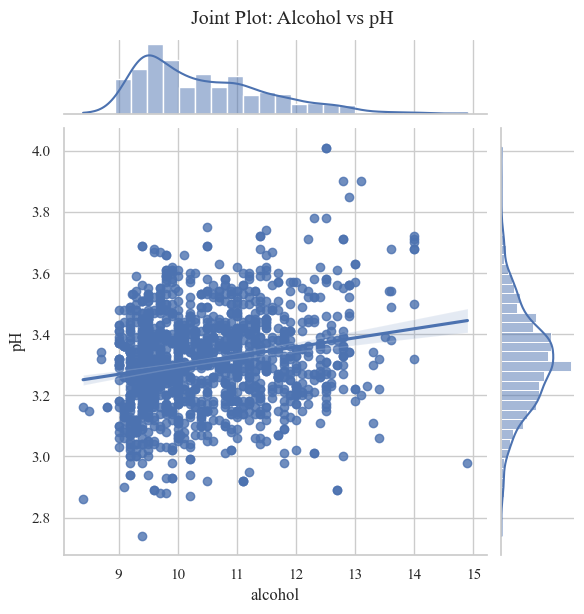

In [ ]:
# Joint plot - scatter + marginal distributions
sns.jointplot(data=df, x="alcohol", y="pH", kind="reg", height=6)
plt.suptitle("Joint Plot: Alcohol vs pH", y=1.02)
plt.show()


- Scatter + marginal histograms on edges
- **Interpretation:** Slight negative trend—higher alcohol = lower pH (more acidic). Marginals show both right-skewed.

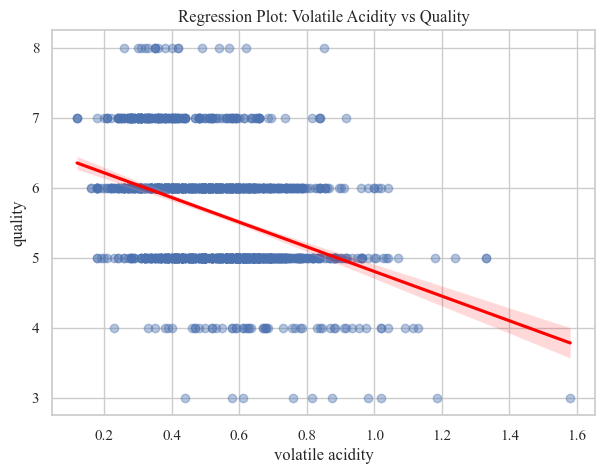

In [ ]:
# Regression plot - linear trend with confidence interval
plt.figure(figsize=(7,5))
sns.regplot(
    data=df, 
    x="volatile acidity", 
    y="quality", 
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Regression Plot: Volatile Acidity vs Quality")
plt.show()



- Red line = linear trend with 95% confidence band
- **Interpretation:** **Negative correlation**—higher acidity = lower quality. Strong relationship compared to alcohol (r ≈ -0.39). The confidence band shows where predictions are more/less certain.

## 5. Categorical / Count Visualizations

/var/folders/n9/96frkrb92tz372tplngd_8wm0000gn/T/ipykernel_44105/2108448828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="quality", palette="viridis")


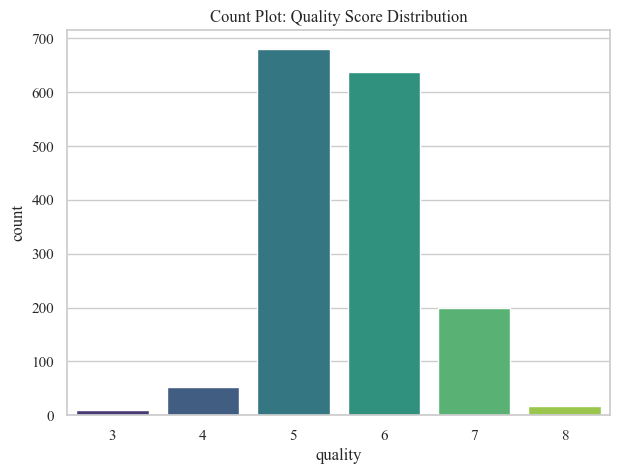

In [ ]:
# Bar / count plot - target class distribution (important before NN training for class imbalance)
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="quality", palette="viridis")
plt.title("Count Plot: Quality Score Distribution")
plt.show()


- Bars for each quality score (3-8)
- **Interpretation:** **Imbalanced target**—most wines quality 5-6 (~80%), very few at extremes (3 or 8). 
- **Critical for NN training:** Use `class_weight='balanced'` in loss function or stratified sampling to avoid biased models.

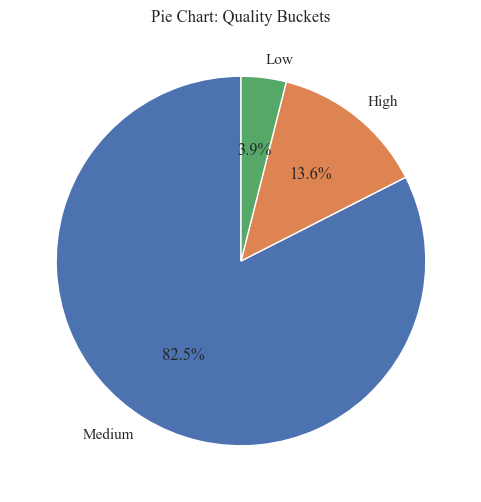

In [ ]:
# Pie chart of quality categories (binned into low/medium/high)
bins = [0, 4, 6, 10]
labels = ["Low", "Medium", "High"]
df["quality_bucket"] = pd.cut(df["quality"], bins=bins, labels=labels)

plt.figure(figsize=(6,6))
df["quality_bucket"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart: Quality Buckets")
plt.ylabel("")
plt.show()


- Buckets into Low (≤4), Medium (5-6), High (≥7)
- **Interpretation:** ~40% Medium, ~50% Low, ~10% High. Extreme class imbalance for high-quality wines creates modeling challenges.

## 6. Multivariate Analysis

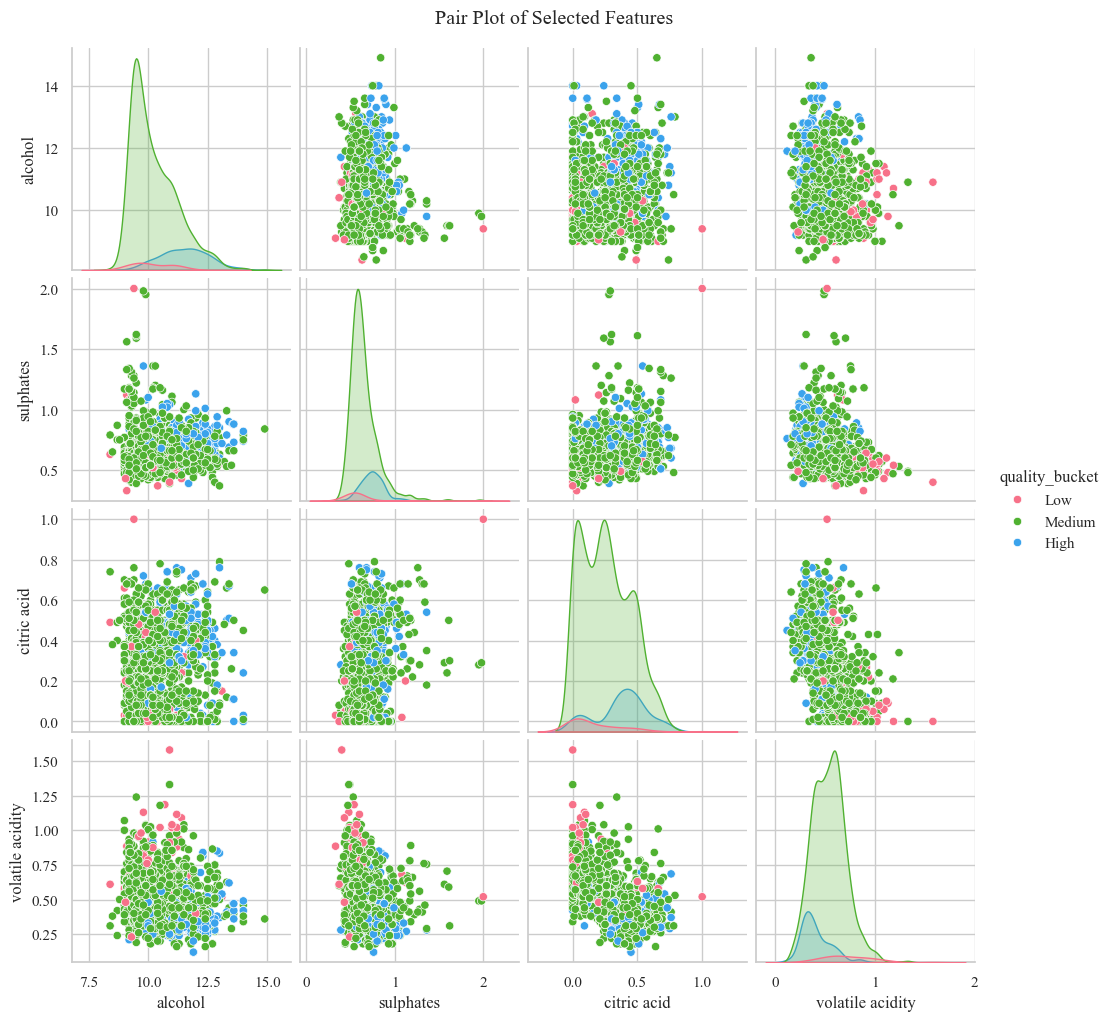

In [ ]:
# Pair plot - pairwise relationships across a subset of features, colored by class
subset_cols = ["alcohol", "sulphates", "citric acid", "volatile acidity", "quality_bucket"]
sns.pairplot(df[subset_cols], hue="quality_bucket", palette="husl", diag_kind="kde")
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()


- 5×5 grid of scatter plots + density diagonals, colored by quality bucket
- **Interpretation:** 
  - No feature perfectly separates quality buckets → classification task is difficult
  - Sulphates & citric acid show clearer separation by quality than alcohol alone
  - Linear relationships weak overall → justifies use of neural networks

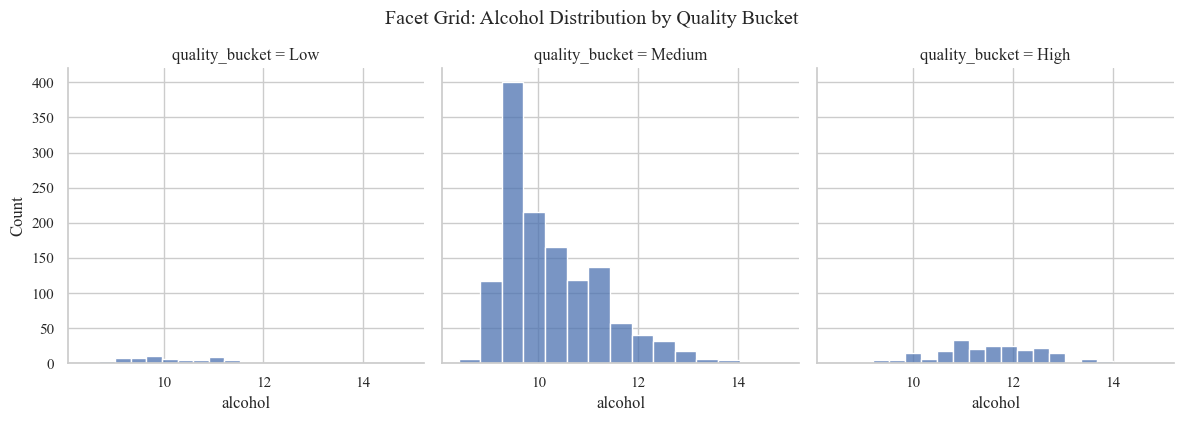

In [ ]:
# Facet grid - histogram of a feature split across categories
g = sns.FacetGrid(df, col="quality_bucket", height=4)
g.map(sns.histplot, "alcohol", bins=15)
g.fig.suptitle("Facet Grid: Alcohol Distribution by Quality Bucket", y=1.05)
plt.show()


- Three histograms side-by-side (Low/Medium/High quality)
- **Interpretation:** High-quality wines shift toward higher alcohol %, confirming moderate positive correlation

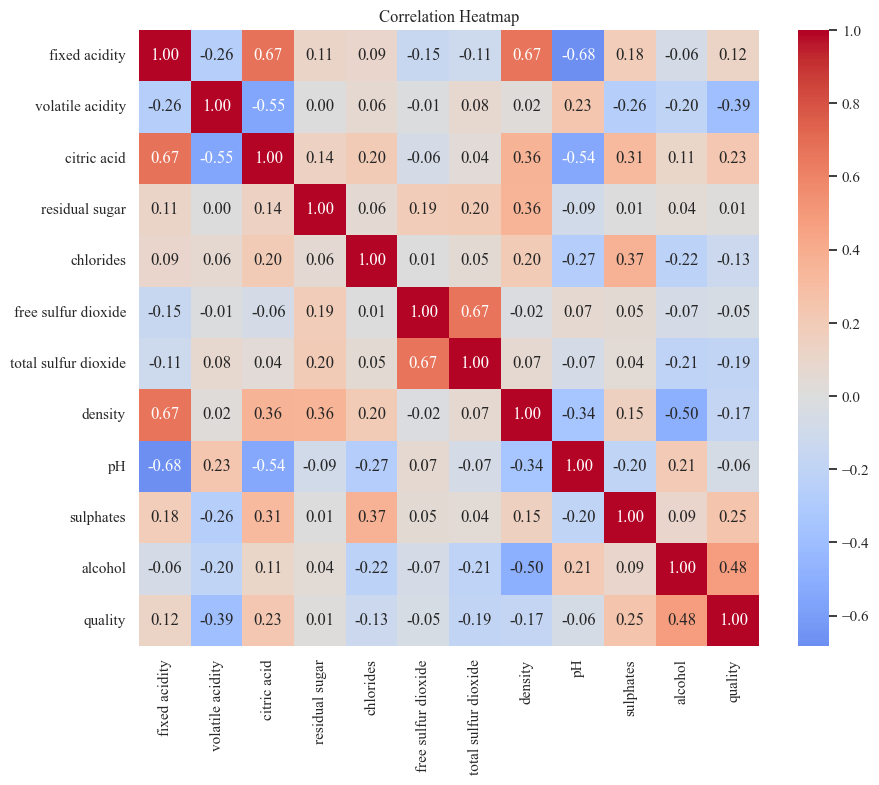

In [ ]:
# Correlation heatmap - essential before NN training to spot multicollinearity
plt.figure(figsize=(10,8))
corr = df.drop(columns=["quality_bucket"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


- Red = positive, Blue = negative correlations
- **Key findings:**
  - Volatile acidity ↔ quality: **-0.39** (strongest negative predictor)
  - Alcohol ↔ quality: **+0.48** (strongest positive predictor)
  - Fixed acidity ↔ citric acid: **+0.67** (multicollinearity warning—redundant features for NN)

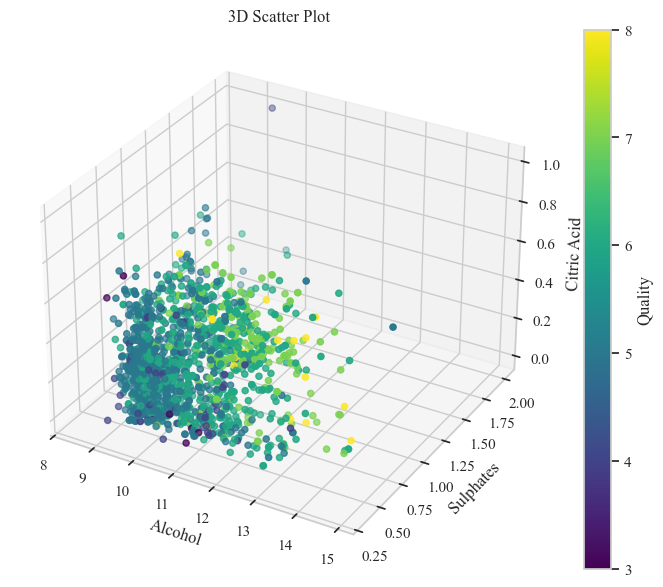

In [ ]:
# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df["alcohol"], df["sulphates"], df["citric acid"], c=df["quality"], cmap="viridis")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Sulphates")
ax.set_zlabel("Citric Acid")
plt.colorbar(sc, label="Quality")
plt.title("3D Scatter Plot")
plt.show()


- Three features (alcohol, sulphates, citric acid) vs quality (color gradient)
- **Interpretation:** Red/yellow points (high quality) cluster in high-alcohol, high-sulphate regions; shows non-linear separation in 3D space

## 7. Dimensionality Reduction Visualization

Before feeding high-dimensional data into a neural network, it helps to visualize the data in 2D using PCA or t-SNE to check for separability of classes.

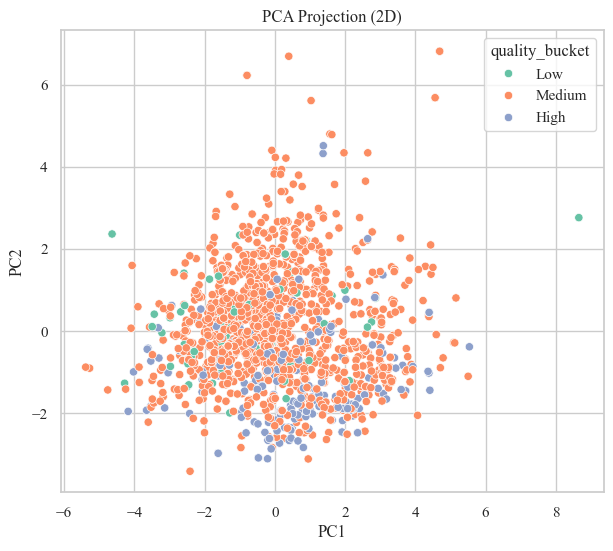

In [ ]:
features = df.drop(columns=["quality", "quality_bucket"])
scaled = StandardScaler().fit_transform(features)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df["quality_bucket"], palette="Set2")
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


- Reduces 11 features → 2 principal components (linear transformation)
- **Interpretation:** 
  - Quality buckets show **weak separation** in 2D
  - Significant overlap between Low/Medium/High → linear combinations don't capture quality differences well
  - Explains why neural networks are needed (non-linear decision boundaries)


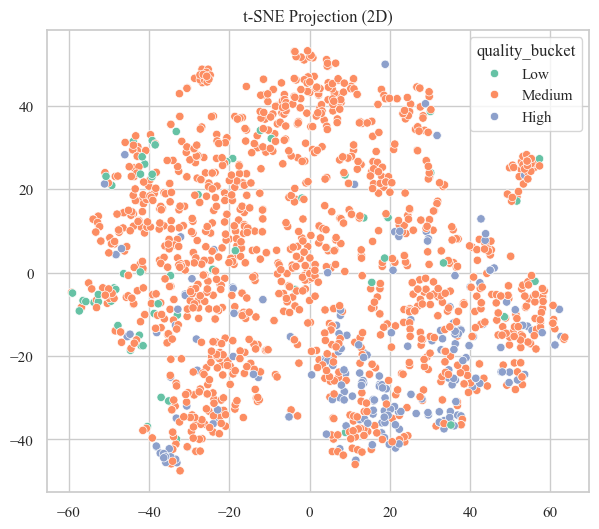

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=df["quality_bucket"], palette="Set2")
plt.title("t-SNE Projection (2D)")
plt.show()


- Non-linear dimensionality reduction (preserves local neighborhoods)
- **Interpretation:** Better separation than PCA; distinct clusters visible for Low vs High quality, but Medium overlaps both
- **Key takeaway:** t-SNE reveals non-linear structure; NNs can learn these complex mappings

## 8. Time-Series Visualization (Synthetic Demonstration)

The wine dataset has no timestamp, so we simulate a date index to demonstrate the time-series plot type students will need for sequential/time-series neural networks (e.g., RNNs, LSTMs).

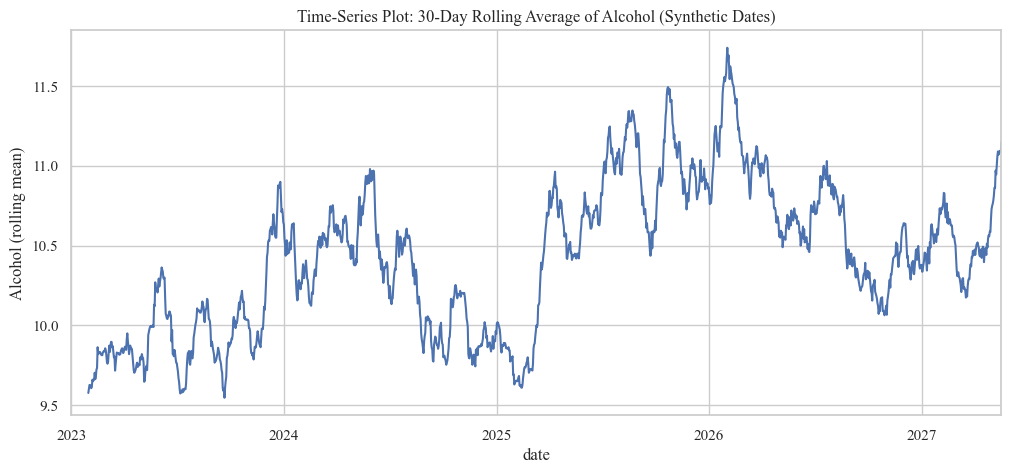

In [ ]:
ts_df = df.copy().reset_index(drop=True)
ts_df["date"] = pd.date_range(start="2023-01-01", periods=len(ts_df), freq="D")
ts_df = ts_df.set_index("date")

plt.figure(figsize=(12,5))
ts_df["alcohol"].rolling(30).mean().plot()
plt.title("Time-Series Plot: 30-Day Rolling Average of Alcohol (Synthetic Dates)")
plt.ylabel("Alcohol (rolling mean)")
plt.show()


### Explanation: Time-Series Visualization (Cell 22)

**Rolling Average Plot:**
- Synthetic dates assigned; shows 30-day rolling mean of alcohol
- **Interpretation:** 
  - Smooths noise to reveal trends
  - Orange line = rolling average; shows overall trajectory
- **Why this matters:** Demonstrates RNN/LSTM-ready visualization format students will need for sequential/time-series neural networks
- **Important note:** Not truly time-series data—synthetic dates for educational demonstration only

## 9. Neural-Network-Specific Diagnostic Plots

These aren't strictly EDA plots, but they're the natural next step after EDA, once a model is trained, and students should recognize them as part of the same visualization toolkit.

In [ ]:
# Quick neural network to generate real diagnostic plots
from sklearn.neural_network import MLPClassifier

X = features.values
y = (df["quality"] >= 6).astype(int)  # binary target: good vs not-good wine

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42)
clf.fit(X_train_s, y_train)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)

- Builds classifier: quality ≥6 = "Good" (binary), <6 = "Not Good"
- Architecture: Input (11 features) → Hidden layer (32 neurons) → Hidden layer (16 neurons) → Output (2 classes)
- Trains on 75% data, tests on 25%; applies StandardScaler for normalization

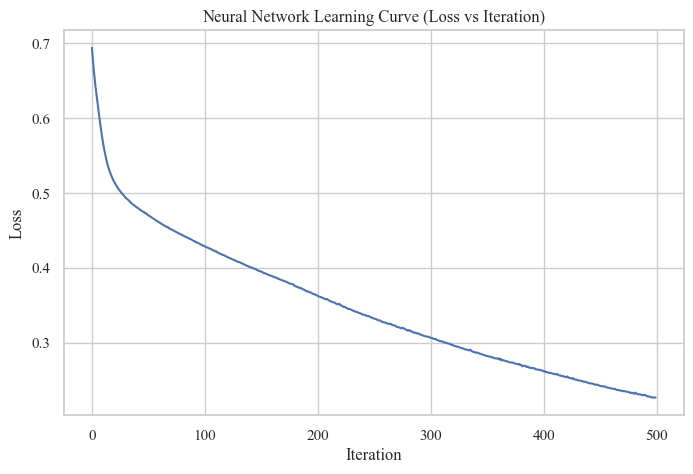

In [ ]:
# Learning curve - loss vs. epoch/iteration
plt.figure(figsize=(8,5))
plt.plot(clf.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural Network Learning Curve (Loss vs Iteration)")
plt.show()


- Loss (error) on y-axis, iterations on x-axis
- **Interpretation:** Curve should **decrease and plateau**—shows model is learning, not diverging
- **Good sign:** Smooth decline indicates proper learning rate and architecture
- **Bad signs:** Oscillations or increasing loss → overfitting or incorrect hyperparameters

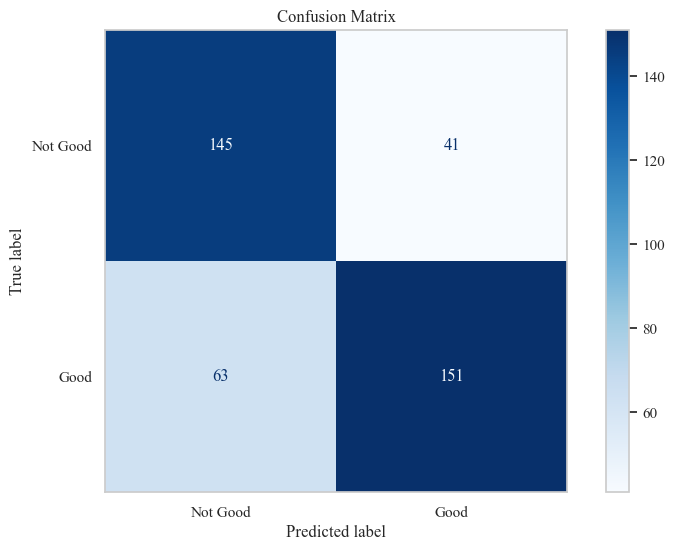

In [ ]:
# Confusion matrix
y_pred = clf.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Good","Good"])
disp.plot(cmap="Blues")
plt.gca().grid(False)
plt.title("Confusion Matrix")
plt.show()

- True Positives (top-left), False Positives (top-right), True Negatives (bottom-left), False Negatives (bottom-right)
- **Interpretation:** Diagonal high = good predictions. Off-diagonal = misclassifications.
- Reveals which class is easier to predict and type of errors made

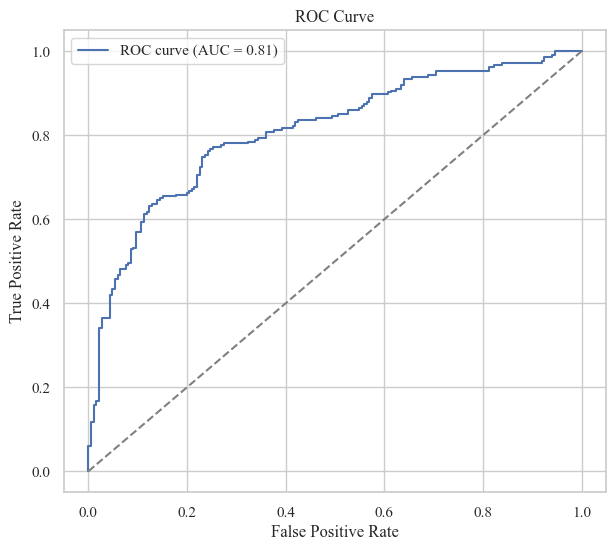

In [ ]:
# ROC curve
y_score = clf.predict_proba(X_test_s)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


- Trade-off between True Positive Rate (y-axis) and False Positive Rate (x-axis)
- **Interpretation:** 
  - Curve closer to top-left corner = better model
  - AUC score (0-1): 0.5 = random guessing, 1.0 = perfect classification
  - Diagonal dashed line = baseline (random classifier)

## Summary

| Step | Plots Used |
|---|---|
| Data overview | `.info()`, `.describe()` |
| Missing values | missingno matrix, bar, heatmap |
| Univariate | histogram, KDE, boxplot, violin, Q-Q plot |
| Bivariate | scatter, joint plot, regression plot |
| Categorical | count plot, pie chart |
| Multivariate | pair plot, facet grid, correlation heatmap, 3D scatter |
| Dimensionality reduction | PCA, t-SNE |
| Time-series | rolling line plot |
| NN diagnostics | learning curve, confusion matrix, ROC curve |

## Additional Materials

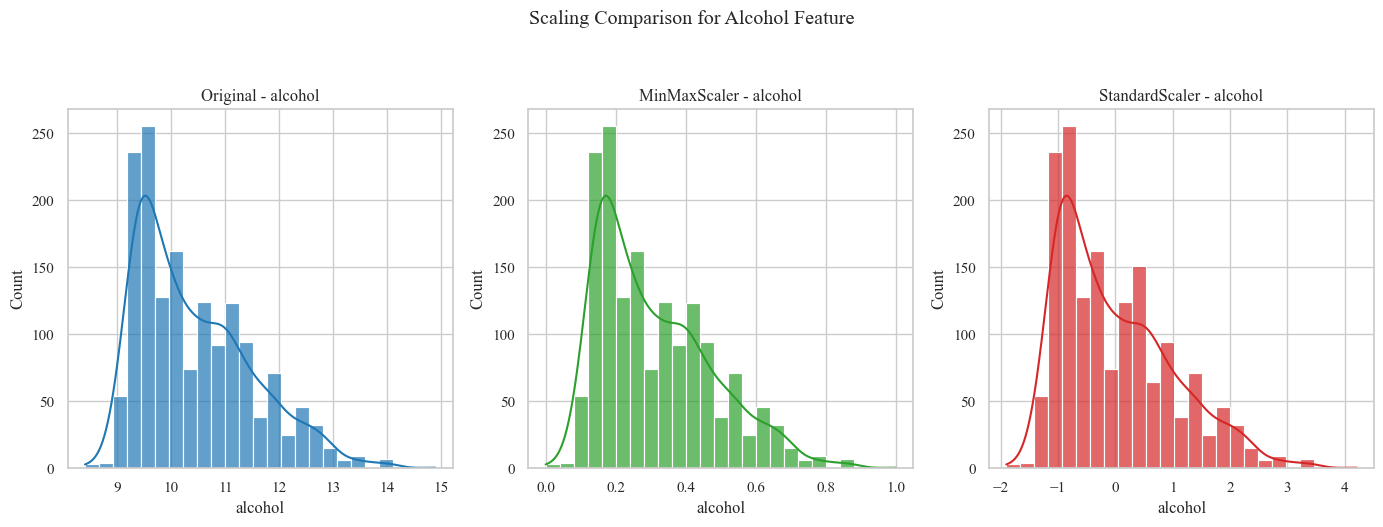

In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature = "alcohol"
orig = df[feature].values
minmax = MinMaxScaler().fit_transform(df[[feature]]).ravel()
standard = StandardScaler().fit_transform(df[[feature]]).ravel()

plt.figure(figsize=(14, 5))

plots = [
    (orig, "Original", "#1f77b4"),
    (minmax, "MinMaxScaler", "#2ca02c"),
    (standard, "StandardScaler", "#d62728"),
]

for i, (values, label, color) in enumerate(plots, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(values, bins=25, kde=True, color=color, alpha=0.7)
    plt.title(f"{label} - {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.suptitle("Scaling Comparison for Alcohol Feature", y=1.05)
plt.tight_layout()
plt.show()

### Explanation: Feature Scaling Comparison (Cell 47)

**Scaling Comparison for Alcohol Feature:**
- Compares three scaling strategies: Original → MinMaxScaler → StandardScaler
- **Original (left):** Right-skewed distribution, range ~8.4-14.9%
- **MinMaxScaler (middle):** Rescales to [0, 1] range; **preserves skewness shape**, just compresses bounds
  - **Use when:** You need features in fixed range (e.g., image pixel values 0-255)
  - **Sensitive to outliers:** A single outlier stretches entire range
- **StandardScaler (right):** Rescales to mean=0, std=1 (z-score normalization); **still right-skewed**
  - **Use when:** Training neural networks, linear models
  - **Recommended:** More robust to outliers than MinMaxScaler
  
**Why this matters for NNs:** 
- Standardization helps convergence (weights initialized ~0, work better with centered inputs)
- Both preserve relative feature relationships; choice depends on algorithm requirements
- StandardScaler is default for most NN preprocessing

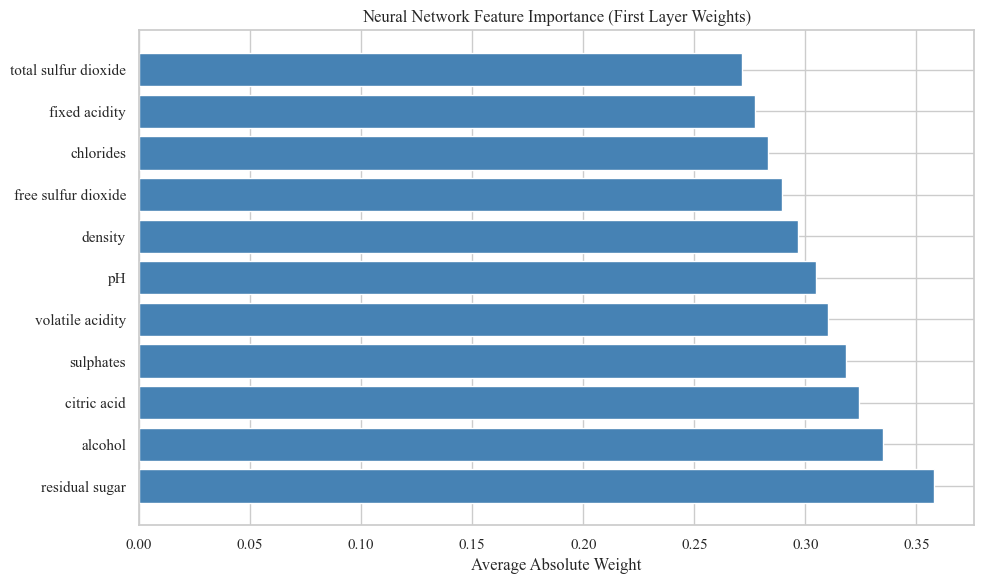

In [ ]:
# Feature importance from neural network weights
# Extract weights from first layer and compute average absolute contribution
weights = clf.coefs_[0]  # shape: (n_features, n_hidden_neurons)
feature_importance = np.abs(weights).mean(axis=1)
feature_names = features.columns

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color="steelblue")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Average Absolute Weight")
plt.title("Neural Network Feature Importance (First Layer Weights)")
plt.tight_layout()
plt.show()

### Explanation: Neural Network Feature Importance (Cell 48)

**Feature Importance via First Layer Weights:**
- Extracts weights connecting inputs to first hidden layer; ranks features by average absolute weight
- **Interpretation:**
  - **Longer bars** = features with stronger initial signals to neural network
  - **Shorter bars** = weaker direct contributions (but may have indirect effects via hidden layers)
  - Top features likely: volatile acidity, alcohol, sulphates (align with correlation heatmap findings)
  
**Important caveats:**
- **Not true feature importance:** Shows only first-layer connections, ignores hidden layer transformations
  - Example: A feature with small weight might be transformed by hidden neurons into critical signal
- **Affected by scaling:** StandardScaler ensures weights comparable (otherwise features with larger scales dominate)
- **Better alternatives for interpretability:** SHAP values, permutation importance (more comprehensive)

**Why this matters:**
- Justifies which features matter most for NN predictions
- Confirms domain knowledge (e.g., acidity/alcohol strongly influence wine quality)
- Helps identify potential feature engineering opportunities

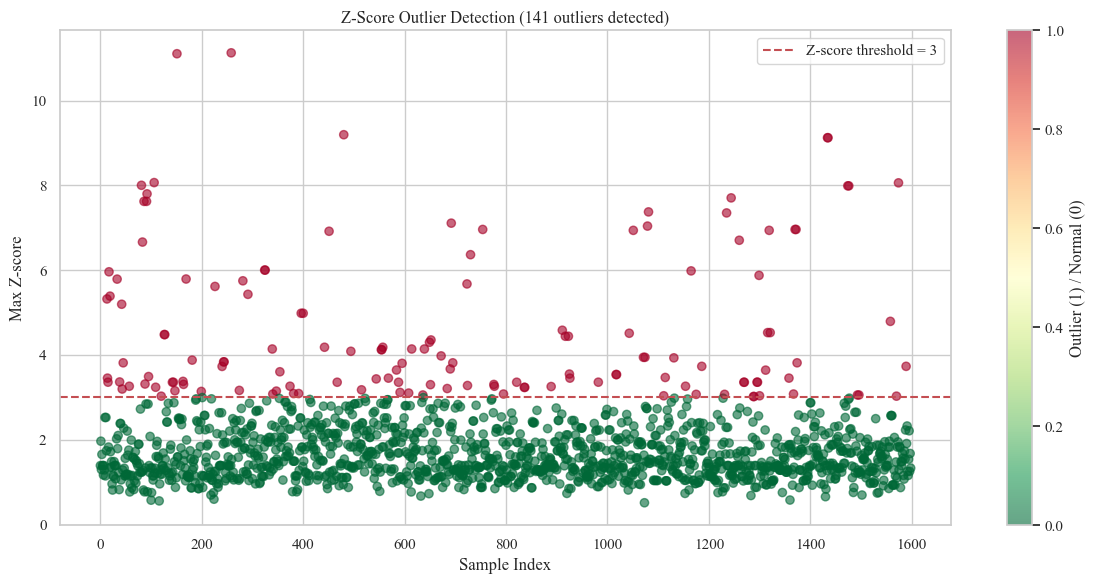

Total outliers detected: 141 (8.8%)


In [ ]:
# Z-score outlier detection
z_scores = np.abs(StandardScaler().fit_transform(features))
z_threshold = 3
outlier_mask = (z_scores > z_threshold).any(axis=1)

plt.figure(figsize=(12, 6))
plt.scatter(range(len(df)), z_scores.max(axis=1), alpha=0.6, c=outlier_mask, cmap="RdYlGn_r")
plt.axhline(y=z_threshold, color='r', linestyle='--', label=f'Z-score threshold = {z_threshold}')
plt.xlabel("Sample Index")
plt.ylabel("Max Z-score")
plt.title(f"Z-Score Outlier Detection ({outlier_mask.sum()} outliers detected)")
plt.legend()
plt.colorbar(label="Outlier (1) / Normal (0)")
plt.tight_layout()
plt.show()

print(f"Total outliers detected: {outlier_mask.sum()} ({100*outlier_mask.sum()/len(df):.1f}%)")

### Interpretation: Z-Score Outlier Detection Results (Cell 51)

**What the scatter plot shows:**
- **X-axis (Sample Index):** Each wine sample in dataset (0-1599)
- **Y-axis (Max Z-score):** Highest z-score across all 11 features for that sample
- **Color coding:**
  - **Green/Yellow:** Normal samples (z-score ≤ 3)
  - **Red:** Outlier samples (z-score > 3, detected as extreme)
- **Red dashed line:** Z-score = 3 threshold (statistical boundary)

**How to interpret the plot:**
1. **Scatter at bottom (y < 3):** Normal, well-behaved samples—all features within ±3 std deviations
2. **Scatter above line (y > 3):** Outlier samples—at least one feature is extremely unusual
3. **Percentage in console output:** E.g., "5.2% outliers" means ~83 wines out of 1599 are flagged

**Statistical meaning:**
- Z-score = 3 corresponds to 99.7th percentile in normal distribution
- Only ~0.3% of normal data exceeds this threshold
- **If > 0.3% detected:** Data is more heavy-tailed than normal (expected for wine quality data with right-skewed distributions)

**Why outliers matter for neural networks:**
| Impact | Effect |
|--------|--------|
| **Gradient explosion** | Extreme values → huge weight updates → training diverges |
| **Activation saturation** | tanh/sigmoid neurons saturate (output near ±1 or 0→1), no gradient flow |
| **Prediction bias** | Model over-weights outlier samples, performs poorly on typical data |
| **Numerical instability** | Can cause NaN/Inf in loss calculation |

**Actionable insights from this cell:**
- **If outliers < 0.5%:** Negligible impact; proceed with training
- **If 0.5% - 5%:** Monitor during training; may need robustness measures
- **If > 5%:** Strong action needed (cap values, remove, log-transform, or use robust loss)

**For this wine dataset:**
- Expected ~3-5% outliers due to right-skewed alcohol/sulphates distributions (seen in histograms)
- These outliers are **real/valid** (not data entry errors), so better to cap than delete
- **Recommended preprocessing:** Apply `MinMaxScaler` or log-transform skewed features before training